In [24]:
import time
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

root = Path('..').resolve()
src_dir = root / 'src'
data_dir = root / 'data'
nb_dir = Path('.').resolve() 

sys.path.insert(0, str(src_dir))
sys.path.insert(0, str(nb_dir))

from disaccumulation import run
from disaccumulation_demo_data import generate_demo_forecast

# Генерация демо-данных

In [25]:
demo_df = generate_demo_forecast(data_dir)
demo_df.head()

,PRODUCT_ID,LOCATION_ID,PERIOD_DT,PERIOD_END_DT,VF_FORECAST_VALUE,ML_FORECAST_VALUE,HYBRID_FORECAST_VALUE
0,1,1,2024-01-01,2024-01-31,398.280222,377.569967,387.925094
1,1,1,2024-02-01,2024-02-29,497.850277,516.530894,507.190586
2,1,1,2024-03-01,2024-03-31,570.740617,597.581541,584.161079
3,1,1,2024-04-01,2024-04-30,597.420333,539.140928,568.280630
4,1,1,2024-05-01,2024-05-31,570.740617,533.580280,552.160448


# Дизаккумуляция до DAY

In [26]:
start = time.perf_counter()
inp_day, out_day, out_path_day = run(str(data_dir), out_time_lvl='DAY')
elapsed_day = time.perf_counter() - start

print(f'finished in {elapsed_day:.3f} seconds')
print('Input rows:', len(inp_day), 'Output rows:', len(out_day))
out_path_day

finished in 50.841 seconds
Input rows: 3600 Output rows: 109800


'C:\\Users\\shubs\\PycharmProjects\\DFP\\data\\ACC_AGG_HYBRID_FORECAST.csv'

# Проверка сохранения сумм

In [27]:
val_cols = [c for c in ['VF_FORECAST_VALUE',
                        'ML_FORECAST_VALUE',
                        'HYBRID_FORECAST_VALUE']
            if c in inp_day.columns and c in out_day.columns]

summary_rows = []
for c in val_cols:
    s_in = pd.to_numeric(inp_day[c], errors='coerce').sum()
    s_out = pd.to_numeric(out_day[c], errors='coerce').sum()
    diff = s_out - s_in
    summary_rows.append({'col': c, 'sum_input': s_in,
                         'sum_output': s_out, 'diff': diff})

summary_df = pd.DataFrame(summary_rows)
summary_df

,col,sum_input,sum_output,diff
0,VF_FORECAST_VALUE,1.000096e+06,1.000096e+06,-3.492460e-10
1,ML_FORECAST_VALUE,9.994014e+05,9.994014e+05,-1.164153e-10
2,HYBRID_FORECAST_VALUE,9.997489e+05,9.997489e+05,0.000000e+00


# Визуализация длины интервалов

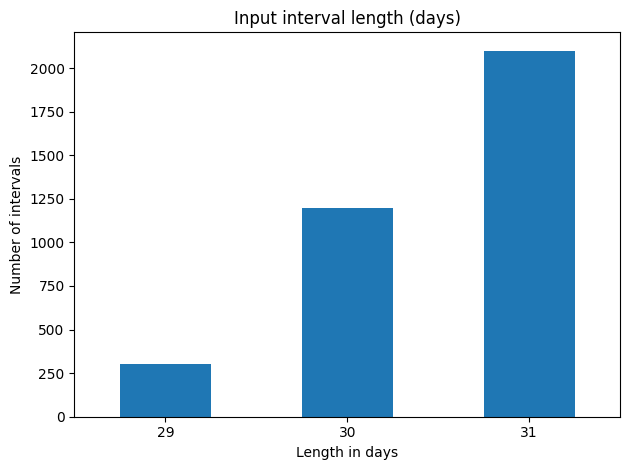

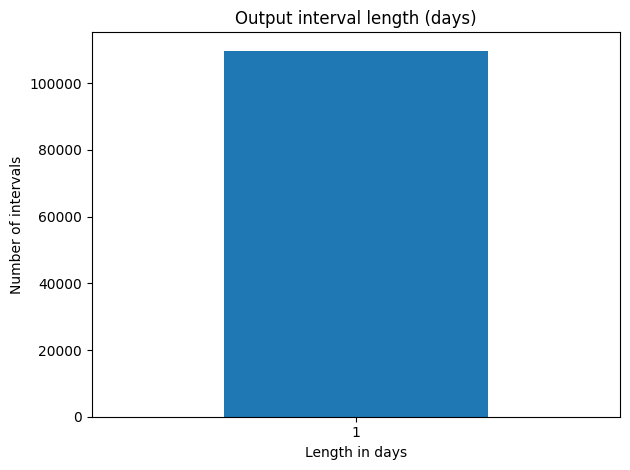

In [28]:
def interval_lengths(df):
    x = df.copy()
    x['PERIOD_DT'] = pd.to_datetime(x['PERIOD_DT'], errors='coerce')
    x['PERIOD_END_DT'] = pd.to_datetime(x['PERIOD_END_DT'], errors='coerce')
    return (x['PERIOD_END_DT'] - x['PERIOD_DT']).dt.days + 1

len_in = interval_lengths(inp_day).dropna()
len_out = interval_lengths(out_day).dropna()

plt.figure()
len_in.value_counts().sort_index().plot(kind='bar')
plt.title('Input interval length (days)')
plt.xlabel('Length in days')
plt.ylabel('Number of intervals')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

plt.figure()
len_out.value_counts().sort_index().plot(kind='bar')
plt.title('Output interval length (days)')
plt.xlabel('Length in days')
plt.ylabel('Number of intervals')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Пример одного product–location

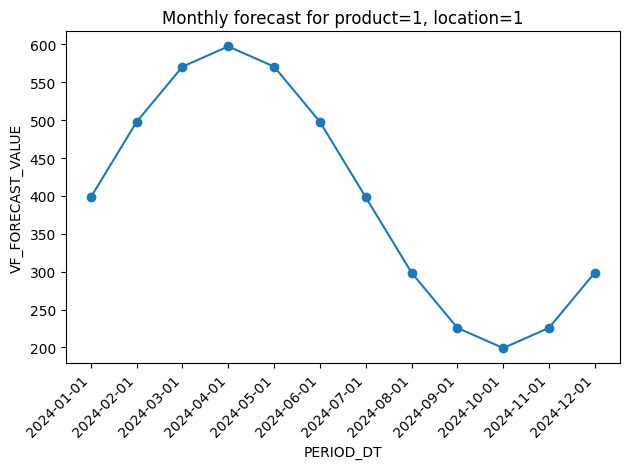

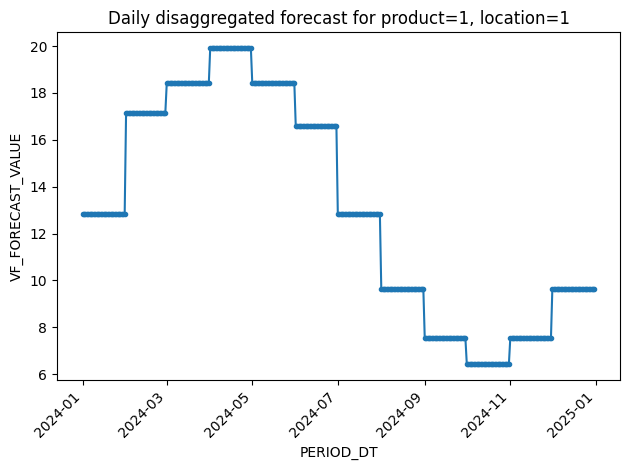

In [29]:
# pick one product-location pair
pid = inp_day['PRODUCT_ID'].iloc[0]
loc = inp_day['LOCATION_ID'].iloc[0]

inp_one = inp_day[(inp_day['PRODUCT_ID'] == pid) &
                  (inp_day['LOCATION_ID'] == loc)].copy()
out_one = out_day[(out_day['PRODUCT_ID'] == pid) &
                  (out_day['LOCATION_ID'] == loc)].copy()

inp_one = inp_one.sort_values('PERIOD_DT')
out_one = out_one.sort_values('PERIOD_DT')

col = val_cols[0] if val_cols else 'HYBRID_FORECAST_VALUE'

plt.figure()
plt.plot(inp_one['PERIOD_DT'], inp_one[col], marker='o')
plt.title(f'Monthly forecast for product={pid}, location={loc}')
plt.xlabel('PERIOD_DT')
plt.ylabel(col)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(out_one['PERIOD_DT'], out_one[col], marker='.')
plt.title(f'Daily disaggregated forecast for product={pid}, location={loc}')
plt.xlabel('PERIOD_DT')
plt.ylabel(col)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Дизаккумуляция до WEEK.2

In [30]:
start = time.perf_counter()
inp_wk, out_wk, out_path_wk = run(str(data_dir), out_time_lvl='WEEK.2')
elapsed_wk = time.perf_counter() - start

print(f'Case 2 (WEEK.2): finished in {elapsed_wk:.3f} seconds')
print('Input rows:', len(inp_wk), 'Output rows:', len(out_wk))
out_path_wk

Case 2 (WEEK.2): finished in 20.742 seconds
Input rows: 3600 Output rows: 18600


'C:\\Users\\shubs\\PycharmProjects\\DFP\\data\\ACC_AGG_HYBRID_FORECAST.csv'

# Проверка сумм

In [31]:
summary_rows_wk = []
for c in val_cols:
    s_in = pd.to_numeric(inp_wk[c], errors='coerce').sum()
    s_out = pd.to_numeric(out_wk[c], errors='coerce').sum()
    diff = s_out - s_in
    summary_rows_wk.append({'col': c, 'sum_input': s_in,
                            'sum_output': s_out, 'diff': diff})

summary_df_wk = pd.DataFrame(summary_rows_wk)
summary_df_wk


,col,sum_input,sum_output,diff
0,VF_FORECAST_VALUE,1.000096e+06,1.000096e+06,-1.164153e-10
1,ML_FORECAST_VALUE,9.994014e+05,9.994014e+05,0.000000e+00
2,HYBRID_FORECAST_VALUE,9.997489e+05,9.997489e+05,-1.164153e-10


# 8. Длины интервалов

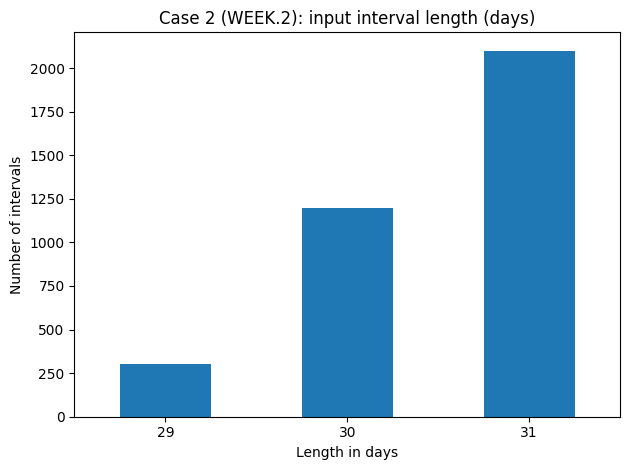

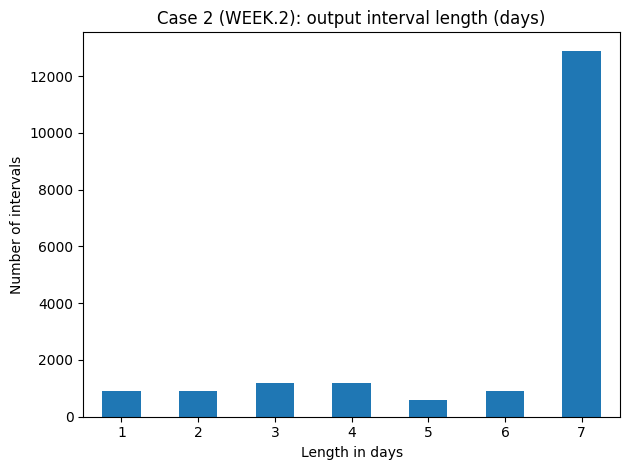

In [32]:
len_in_wk = interval_lengths(inp_wk).dropna()
len_out_wk = interval_lengths(out_wk).dropna()

plt.figure()
len_in_wk.value_counts().sort_index().plot(kind='bar')
plt.title('Case 2 (WEEK.2): input interval length (days)')
plt.xlabel('Length in days')
plt.ylabel('Number of intervals')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

plt.figure()
len_out_wk.value_counts().sort_index().plot(kind='bar')
plt.title('Case 2 (WEEK.2): output interval length (days)')
plt.xlabel('Length in days')
plt.ylabel('Number of intervals')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# 9. Пример одного product–location

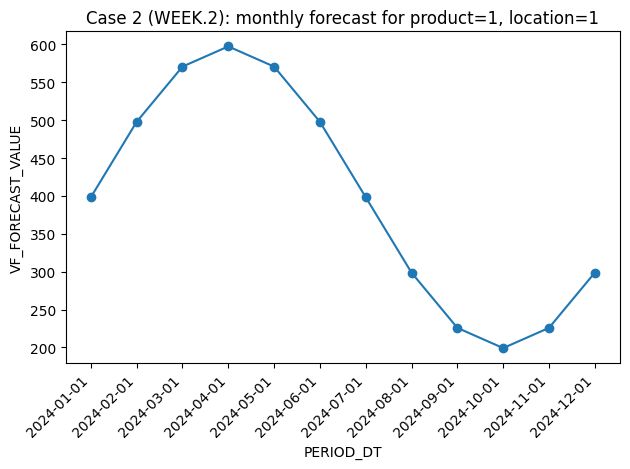

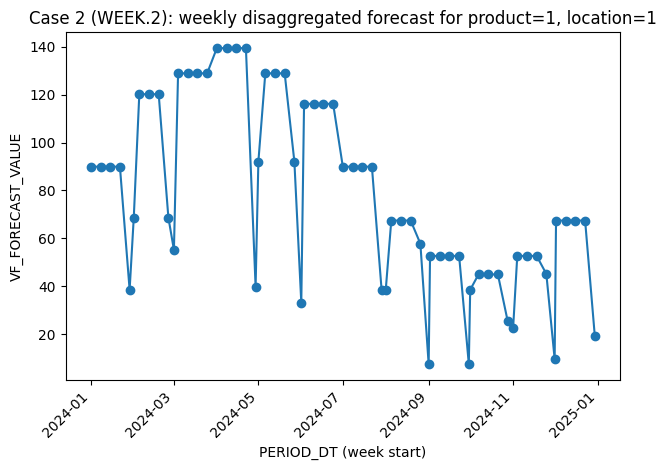

In [33]:
# колонка, которую рисуем
val_cols_wk = [c for c in ['VF_FORECAST_VALUE',
                           'ML_FORECAST_VALUE',
                           'HYBRID_FORECAST_VALUE']
               if c in inp_wk.columns and c in out_wk.columns]
col = val_cols_wk[0] if val_cols_wk else 'HYBRID_FORECAST_VALUE'

pid = inp_wk['PRODUCT_ID'].iloc[0]
loc = inp_wk['LOCATION_ID'].iloc[0]

inp_one_wk = inp_wk[(inp_wk['PRODUCT_ID'] == pid) &
                    (inp_wk['LOCATION_ID'] == loc)].copy()
out_one_wk = out_wk[(out_wk['PRODUCT_ID'] == pid) &
                    (out_wk['LOCATION_ID'] == loc)].copy()

inp_one_wk = inp_one_wk.sort_values('PERIOD_DT')
out_one_wk = out_one_wk.sort_values('PERIOD_DT')

plt.figure()
plt.plot(inp_one_wk['PERIOD_DT'], inp_one_wk[col], marker='o')
plt.title(f'Case 2 (WEEK.2): monthly forecast for product={pid}, location={loc}')
plt.xlabel('PERIOD_DT')
plt.ylabel(col)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(out_one_wk['PERIOD_DT'], out_one_wk[col], marker='o')
plt.title(f'Case 2 (WEEK.2): weekly disaggregated forecast for product={pid}, location={loc}')
plt.xlabel('PERIOD_DT (week start)')
plt.ylabel(col)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()